# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
#paralelización
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as nltk_sw

In [2]:
# ── Configuración global ──────────────────────────────────────────────────────
PATH    = r'C:\\Users\\luis3\\Downloads\\RI26A\\Recuperacion_Informacion\\data\\libros_gutenberg'
WORKERS = os.cpu_count()   # todos los núcleos disponibles
STOP    = set(nltk_sw.words('english'))
print(f'Núcleos disponibles: {WORKERS}')

# ── Carga paralela de archivos (I/O bound → ThreadPoolExecutor) ───────────────
def leer_archivo(args):
    path, archivo = args
    with open(os.path.join(path, archivo), 'r', encoding='utf-8', errors='ignore') as f:
        return archivo, f.read()
# Listar archivos y preparar argumentos para la función de lectura
files = [f for f in os.listdir(PATH) if f.endswith('.txt')]
args  = [(PATH, f) for f in files]
# Leer archivos en paralelo
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    resultados = list(pool.map(leer_archivo, args))

titulos = [r[0] for r in resultados]
corpus  = [r[1] for r in resultados]

print(f'Corpus cargado: {len(corpus)} documentos')

Núcleos disponibles: 4
Corpus cargado: 998 documentos


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [23]:
# --- TF: frecuencia de términos (conteos crudos) ---
count_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20000
)
# Ajustar y transformar el corpus para obtener la matriz TF
matriz_tf = count_vectorizer.fit_transform(corpus)
vocabulario = count_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF
df_tf = pd.DataFrame(
    matriz_tf.toarray(),
    index=titulos,
    columns=vocabulario
)

print('Matriz TF (frecuencia de términos):')
print(f'Dimensiones: {df_tf.shape}')
df_tf.head()

Matriz TF (frecuencia de términos):
Dimensiones: (998, 20000)


,00,000,01,02,03,04,05,06,07,08,...,étions,étrange,été,évêque,êtes,être,île,último,über,þe
10002.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10007.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10150.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1023.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1027.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# --- DF: Document Frequency (en cuántos documentos aparece cada término) ---
df_freq = (matriz_tf.toarray() > 0).sum(axis=0)
# Crear un Series para visualizar los términos más comunes por DF
df_df = pd.Series(df_freq, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos por Document Frequency (DF):')
print(df_df.head(20))

Top 20 términos por Document Frequency (DF):
título     998
id         998
good       888
way        882
work       866
best       858
large      857
used       853
taken      851
read       841
fact       835
present    830
new        829
country    825
makes      823
person     822
old        821
know       821
make       816
man        815
dtype: int64


In [25]:
# --- IDF: Inverse Document Frequency ---
N = len(corpus)
idf_valores = np.log((N + 1) / (df_freq + 1)) + 1  # fórmula sklearn
# Crear un Series para visualizar los términos con mayor IDF (más raros/específicos)
df_idf = pd.Series(idf_valores, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos con mayor IDF (más raros/específicos):')
print(df_idf.head(20))

Top 20 términos con mayor IDF (más raros/específicos):
sinasabi       7.213608
sinabi         7.213608
dounia         7.213608
avelyn         7.213608
sherringham    7.213608
seyton         7.213608
siyáng         7.213608
siyá           7.213608
siyang         7.213608
edris          7.213608
dólokhov       7.213608
sergey         7.213608
sequoia        7.213608
babae          7.213608
senter         7.213608
bagay          7.213608
bagarag        7.213608
snagsby        7.213608
smallweed      7.213608
bahay          7.213608
dtype: float64


In [26]:
# --- TF-IDF con sklearn ---
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    sublinear_tf=True
)
# Ajustar y transformar el corpus para obtener la matriz TF-IDF
matriz_tfidf = tfidf_vectorizer.fit_transform(corpus)
# Obtener el vocabulario de TF-IDF
vocab_tfidf  = tfidf_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF-IDF
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=titulos,
    columns=vocab_tfidf
)

print('Matriz TF-IDF:')
print(f'Dimensiones: {df_tfidf.shape}')
df_tfidf.head()

Matriz TF-IDF:
Dimensiones: (998, 20000)


,00,000,01,02,03,04,05,06,07,08,...,étions,étrange,été,évêque,êtes,être,île,último,über,þe
10002.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10007.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10150.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1023.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1027.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# Comparación TF vs TF-IDF para una palabra de ejemplo
palabra = 'murder'

if palabra in df_tf.columns and palabra in df_tfidf.columns:
    comp = pd.DataFrame({
        'TF':     df_tf[palabra],
        'TF-IDF': df_tfidf[palabra]
    })
    print(f"Comparación TF vs TF-IDF para la palabra '{palabra}':")
    print(comp[comp['TF'] > 0].sort_values('TF-IDF', ascending=False).head(10))
else:
    print(f"La palabra '{palabra}' no está en el vocabulario. Prueba otra.")

Comparación TF vs TF-IDF para la palabra 'murder':
           TF    TF-IDF
23078.txt   2  0.060675
26468.txt   2  0.054638
67160.txt   3  0.043451
32562.txt   9  0.042410
78088.txt   4  0.041281
66446.txt   3  0.038485
50603.txt  41  0.038369
9870.txt    2  0.036591
78220.txt  69  0.033460
3289.txt   39  0.030964


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [28]:
# consulta de lo deseado a buscar
CONSULTA = 'Zarathustra'
TOP_N = 10

# Construir el vector de consulta en el mismo espacio TF-IDF
vector_consulta = tfidf_vectorizer.transform([CONSULTA])

# Calcular similitud coseno
similitudes = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

# Ranking
indices_top = similitudes.argsort()[::-1][:TOP_N]

ranking_tfidf = pd.DataFrame({
    'Documento': [titulos[i] for i in indices_top],
    'Score TF-IDF': [similitudes[i] for i in indices_top]
})
ranking_tfidf.index = range(1, TOP_N + 1)
ranking_tfidf.index.name = 'Rank'

print(f"Ranking TF-IDF para: '{CONSULTA}'")
ranking_tfidf

Ranking TF-IDF para: 'Zarathustra'


,Documento,Score TF-IDF
Rank,,
1,9963.txt,0.0
2,9911.txt,0.0
3,9904.txt,0.0
4,9870.txt,0.0
5,9830.txt,0.0
6,98.txt,0.0
7,9799.txt,0.0
8,9774.txt,0.0
9,9695.txt,0.0


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.
### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [ ]:
# --- Tokenización personalizada (sin sklearn) ---
def tokenizar(texto):
    texto = texto.lower()
    tokens = re.findall(r'\b[a-z]+\b', texto)
    stop = set(nltk_sw.words('english'))  # ~180 stopwords automáticas
    return [t for t in tokens if t not in stop and len(t) > 2]
# Tokenizar todo el corpus
docs_tokens = [tokenizar(doc) for doc in corpus]
print(f'Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):')
print(docs_tokens[0][:10])

Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):
['house', 'borderland', 'house', 'borderland', 'william', 'hope', 'hodgson', 'manuscript', 'discovered', 'messrs']


In [31]:
# --- Paso 2: Longitudes de documentos y promedio ---
doc_lengths = [len(tokens) for tokens in docs_tokens]
avgdl = sum(doc_lengths) / len(doc_lengths)

print(f'Longitud promedio de documentos: {avgdl:.0f} tokens')
print(f'Doc más corto: {min(doc_lengths)} tokens')
print(f'Doc más largo: {max(doc_lengths)} tokens')

Longitud promedio de documentos: 37948 tokens
Doc más corto: 18 tokens
Doc más largo: 1239064 tokens


In [32]:
# --- Paso 3: TF por documento (conteo de cada término) ---
tf_docs = [Counter(tokens) for tokens in docs_tokens]

print('TF del documento 0 (top 10 palabras):')
print(tf_docs[0].most_common(10))

TF del documento 0 (top 10 palabras):
[('could', 175), ('time', 161), ('sun', 149), ('seemed', 145), ('great', 143), ('came', 132), ('one', 128), ('though', 127), ('house', 125), ('upon', 125)]


In [33]:
# --- Paso 4: DF e IDF de BM25 ---
N = len(corpus)

# DF: en cuántos documentos aparece cada término
df_bm25 = Counter()
for tf in tf_docs:
    for term in tf:
        df_bm25[term] += 1

# IDF de BM25: log((N - df + 0.5) / (df + 0.5) + 1)
def idf_bm25(term):
    df = df_bm25.get(term, 0)
    return math.log((N - df + 0.5) / (df + 0.5) + 1)

print('DF e IDF BM25 calculados')
print(f"IDF de 'murder': {idf_bm25('murder'):.4f}")
print(f"IDF de 'said'  : {idf_bm25('said'):.4f}")

DF e IDF BM25 calculados
IDF de 'murder': 0.7052
IDF de 'said'  : 0.2165


In [34]:
# --- Paso 5: Parámetros BM25 ---
k1 = 1.5   # controla la saturación de TF (típico: 1.2 - 2.0)
b  = 0.75  # controla la normalización por longitud (típico: 0.75)

print(f'Parámetros BM25: k1={k1}, b={b}')

Parámetros BM25: k1=1.5, b=0.75


In [35]:
# --- Paso 6: Score BM25 para un documento ---
def score_bm25_doc(query_terms, doc_idx):
    score = 0
    tf = tf_docs[doc_idx]
    dl = doc_lengths[doc_idx]
    for term in query_terms:
        if term not in tf:
            continue
        tf_term = tf[term]
        idf = idf_bm25(term)
        numerador   = tf_term * (k1 + 1)
        denominador = tf_term + k1 * (1 - b + b * dl / avgdl)
        score += idf * (numerador / denominador)
    return score

In [36]:
# --- Paso 7: Score BM25 para todos los documentos ---
def buscar_bm25(consulta, top_n=10):
    query_terms = tokenizar(consulta)
    scores = [
        (i, score_bm25_doc(query_terms, i))
        for i in range(len(corpus))
    ]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_n]

In [37]:
# --- Paso 8: Ranking BM25 ---
resultados_bm25 = buscar_bm25(CONSULTA, TOP_N)
# Crear DataFrame para mostrar resultados
ranking_bm25 = pd.DataFrame({
    'Documento':  [titulos[i] for i, _ in resultados_bm25],
    'Score BM25': [score     for _, score in resultados_bm25]
})
ranking_bm25.index = range(1, TOP_N + 1)
ranking_bm25.index.name = 'Rank'

print(f"Ranking BM25 para: '{CONSULTA}'")
ranking_bm25

Ranking BM25 para: 'Zarathustra'


,Documento,Score BM25
Rank,,
1,18137.txt,11.918264
2,20228.txt,8.148650
3,6737.txt,7.774246
4,19076.txt,7.552784
5,47584.txt,7.258562
6,4300.txt,4.872520
7,3444.txt,3.172081
8,10002.txt,0.000000
9,10007.txt,0.000000


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

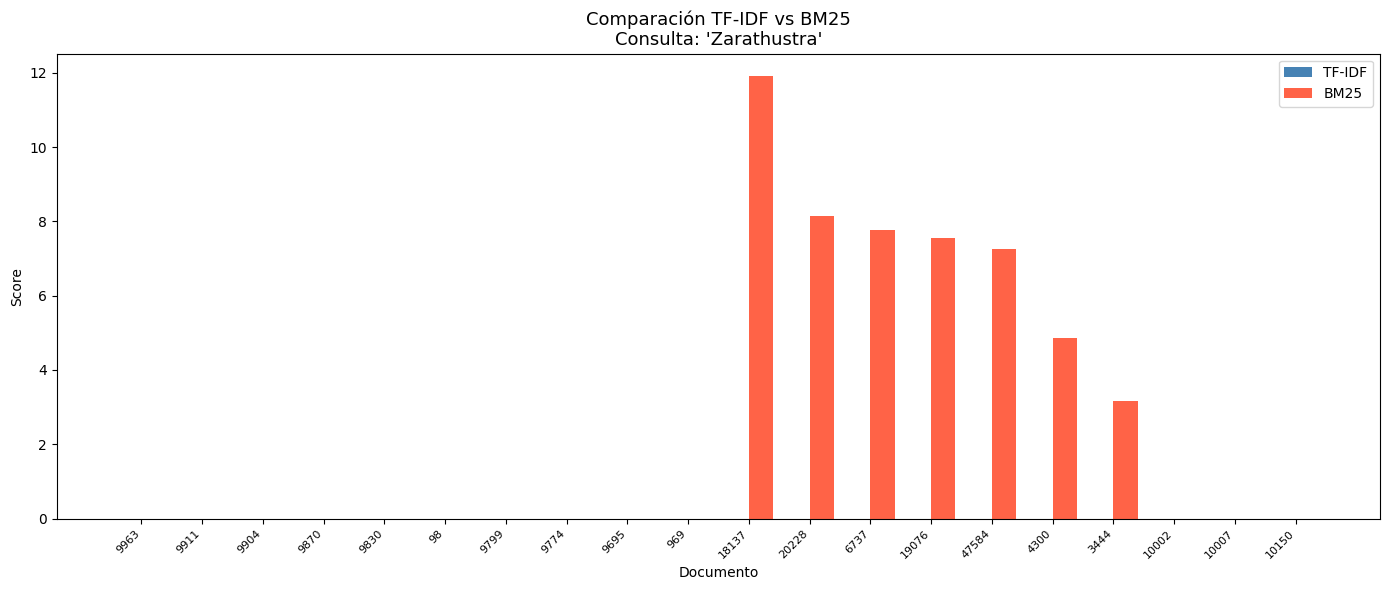

In [38]:
# Unir rankings por documento para comparar
top_docs_tfidf = ranking_tfidf['Documento'].tolist()
top_docs_bm25  = ranking_bm25['Documento'].tolist()
todos_docs     = list(dict.fromkeys(top_docs_tfidf + top_docs_bm25))  # sin duplicados

# Scores TF-IDF para todos los docs del top combinado
scores_tfidf_dict = dict(zip(ranking_tfidf['Documento'], ranking_tfidf['Score TF-IDF']))
scores_bm25_dict  = dict(zip(ranking_bm25['Documento'],  ranking_bm25['Score BM25']))
# Preparar datos para el gráfico
scores_tfidf_plot = [scores_tfidf_dict.get(d, 0) for d in todos_docs]
scores_bm25_plot  = [scores_bm25_dict.get(d, 0)  for d in todos_docs]

# Etiquetas cortas para el gráfico
labels = [d.replace('.txt', '').split('_', 1)[-1][:25] for d in todos_docs]

x = np.arange(len(todos_docs))
ancho = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
barras1 = ax.bar(x - ancho/2, scores_tfidf_plot, ancho, label='TF-IDF', color='steelblue')
barras2 = ax.bar(x + ancho/2, scores_bm25_plot,  ancho, label='BM25',   color='tomato')

ax.set_title(f"Comparación TF-IDF vs BM25\nConsulta: '{CONSULTA}'", fontsize=13)
ax.set_xlabel('Documento')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Tabla comparativa de rankings
df_comparacion = pd.DataFrame({
    'Rank TF-IDF': range(1, TOP_N + 1),
    'Doc TF-IDF':  ranking_tfidf['Documento'].values,
    'Score TF-IDF': ranking_tfidf['Score TF-IDF'].round(4).values,
    'Rank BM25':   range(1, TOP_N + 1),
    'Doc BM25':    ranking_bm25['Documento'].values,
    'Score BM25':  ranking_bm25['Score BM25'].round(4).values,
})

print('Comparación de rankings:')
df_comparacion

Comparación de rankings:


,Rank TF-IDF,Doc TF-IDF,Score TF-IDF,Rank BM25,Doc BM25,Score BM25
0,1,9963.txt,0.0,1,18137.txt,11.9183
1,2,9911.txt,0.0,2,20228.txt,8.1486
2,3,9904.txt,0.0,3,6737.txt,7.7742
3,4,9870.txt,0.0,4,19076.txt,7.5528
4,5,9830.txt,0.0,5,47584.txt,7.2586
5,6,98.txt,0.0,6,4300.txt,4.8725
6,7,9799.txt,0.0,7,3444.txt,3.1721
7,8,9774.txt,0.0,8,10002.txt,0.0000
8,9,9695.txt,0.0,9,10007.txt,0.0000
9,10,969.txt,0.0,10,10150.txt,0.0000
